In [35]:
import random
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

In [36]:
#Loading dataset

df = pd.read_csv("diabetes.csv")
print("✅ Loaded diabetes.csv successfully!")
print(f"   Shape: {df.shape}")

✅ Loaded diabetes.csv successfully!
   Shape: (768, 9)


In [37]:
#Data Cleaning

zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Missing value fill with Per-class median instead of Global median

for col in zero_cols:
    df[col] = df.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

In [38]:
# Outlier handling

def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    for col in columns:
        Q1  = df_clean[col].quantile(0.25)
        Q3  = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 2.5 * IQR, Q3 + 2.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

df = remove_outliers_iqr(df, ["Glucose", "BloodPressure", "BMI", "Insulin"])

print(f"✅ After cleaning — Shape: {df.shape}")

✅ After cleaning — Shape: (739, 9)


In [39]:
# Feature Engineering - Adding hidden relationships

df["Glucose_BMI"]       = df["Glucose"] * df["BMI"]
df["BMI_Age"]           = df["BMI"] * df["Age"]
df["Glucose_Age"]       = df["Glucose"] * df["Age"]
df["Insulin_Glucose"]   = df["Insulin"] / (df["Glucose"] + 1)
df["BP_per_Age"]        = df["BloodPressure"] / (df["Age"] + 1)

print("✅ Feature engineering completed")

✅ Feature engineering completed


In [40]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(f"\n   Features: {X.shape[1]}")
print(f"\n--- Class Distribution ---")
print(y.value_counts())


   Features: 13

--- Class Distribution ---
Outcome
0    488
1    251
Name: count, dtype: int64


In [41]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
# Using SMOTE to fix imbalanced data

smote = SMOTE(random_state=42, k_neighbors=4)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
 
print(f"\n--- After SMOTE ---")
print(pd.Series(y_train_bal).value_counts())


--- After SMOTE ---
Outcome
0    390
1    390
Name: count, dtype: int64


In [43]:
# Scaling - Using RobustScaler instead of StandardScaler to fix outliers

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)
 
print(f"\n✅ Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")


✅ Train: (780, 13) | Test: (148, 13)


In [44]:
# Feature Selection

K = 8
 
selector = SelectKBest(score_func=f_classif, k=K)
X_train_sel = selector.fit_transform(X_train_scaled, y_train_bal)
X_test_sel  = selector.transform(X_test_scaled)
 
feature_names  = X.columns.tolist()
selected_mask  = selector.get_support()
selected_feats = [feature_names[i] for i, m in enumerate(selected_mask) if m]
 
print(f"\n--- Feature Selection (Top {K}) ---")
print(f"   Selected: {selected_feats}")



--- Feature Selection (Top 8) ---
   Selected: ['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Glucose_BMI', 'BMI_Age', 'Glucose_Age', 'Insulin_Glucose']


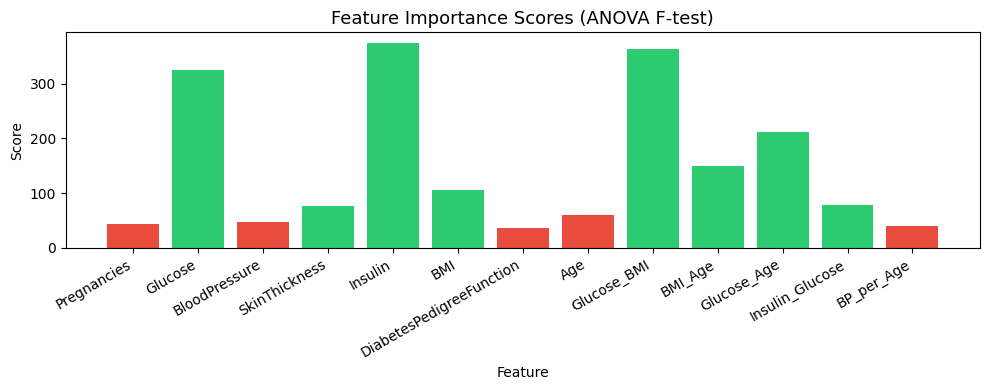

   📊 Saved: feature_scores.png


In [45]:
#Plotting the same

scores = selector.scores_
plt.figure(figsize=(10, 4))
colors = ["#2ecc71" if m else "#e74c3c" for m in selected_mask]
plt.bar(feature_names, scores, color=colors)
plt.title("Feature Importance Scores (ANOVA F-test)", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("feature_scores.png", dpi=120)
plt.show()
print("   📊 Saved: feature_scores.png")

In [46]:
# KNN Grid Search

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print("\n⏳ Tuning KNN...")
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric':      ['euclidean', 'manhattan', 'minkowski'],
    'weights':     ['uniform', 'distance']
}
knn_grid  = GridSearchCV(KNeighborsClassifier(), knn_params, cv=cv, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_sel, y_train_bal)
best_knn  = knn_grid.best_estimator_
knn_preds = best_knn.predict(X_test_sel)
print(f"   Best KNN: {knn_grid.best_params_}")
print(f"   CV Accuracy: {knn_grid.best_score_*100:.2f}%")


⏳ Tuning KNN...


   Best KNN: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
   CV Accuracy: 90.77%


In [47]:
# SVM Grid Search

print("\n⏳ Tuning SVM...")
svm_params = {
    'C':      [0.1, 0.5, 1, 5, 10, 50],
    'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'poly']
}
svm_grid  = GridSearchCV(SVC(probability=True), svm_params, cv=cv, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_sel, y_train_bal)
best_svm  = svm_grid.best_estimator_
svm_preds = best_svm.predict(X_test_sel)
print(f"   Best SVM: {svm_grid.best_params_}")
print(f"   CV Accuracy: {svm_grid.best_score_*100:.2f}%")
 
print("\n✅ Both models trained!")


⏳ Tuning SVM...
   Best SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
   CV Accuracy: 89.87%

✅ Both models trained!


In [48]:
# Soft Voting

print("\n⏳ Building Voting Ensemble...")
ensemble = VotingClassifier(
    estimators=[('knn', best_knn), ('svm', best_svm)],
    voting='soft'
)
ensemble.fit(X_train_sel, y_train_bal)
ensemble_preds = ensemble.predict(X_test_sel)
print("✅ Ensemble trained!")


⏳ Building Voting Ensemble...
✅ Ensemble trained!


In [49]:
# Evaluating the models

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc * 100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Diabetes", "Diabetes"]))
    return acc
 
knn_acc      = evaluate_model("KNN (Tuned)", y_test, knn_preds)
svm_acc      = evaluate_model("SVM (Tuned)", y_test, svm_preds)
ensemble_acc = evaluate_model("Voting Ensemble (KNN + SVM)", y_test, ensemble_preds)


  KNN (Tuned)
  Accuracy : 81.08%

  Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.81      0.85        98
    Diabetes       0.68      0.82      0.75        50

    accuracy                           0.81       148
   macro avg       0.79      0.81      0.80       148
weighted avg       0.83      0.81      0.81       148


  SVM (Tuned)
  Accuracy : 83.78%

  Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.85      0.87        98
    Diabetes       0.73      0.82      0.77        50

    accuracy                           0.84       148
   macro avg       0.82      0.83      0.82       148
weighted avg       0.84      0.84      0.84       148


  Voting Ensemble (KNN + SVM)
  Accuracy : 83.78%

  Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.85      0.87        98
    Diabetes       0.73      0.82     

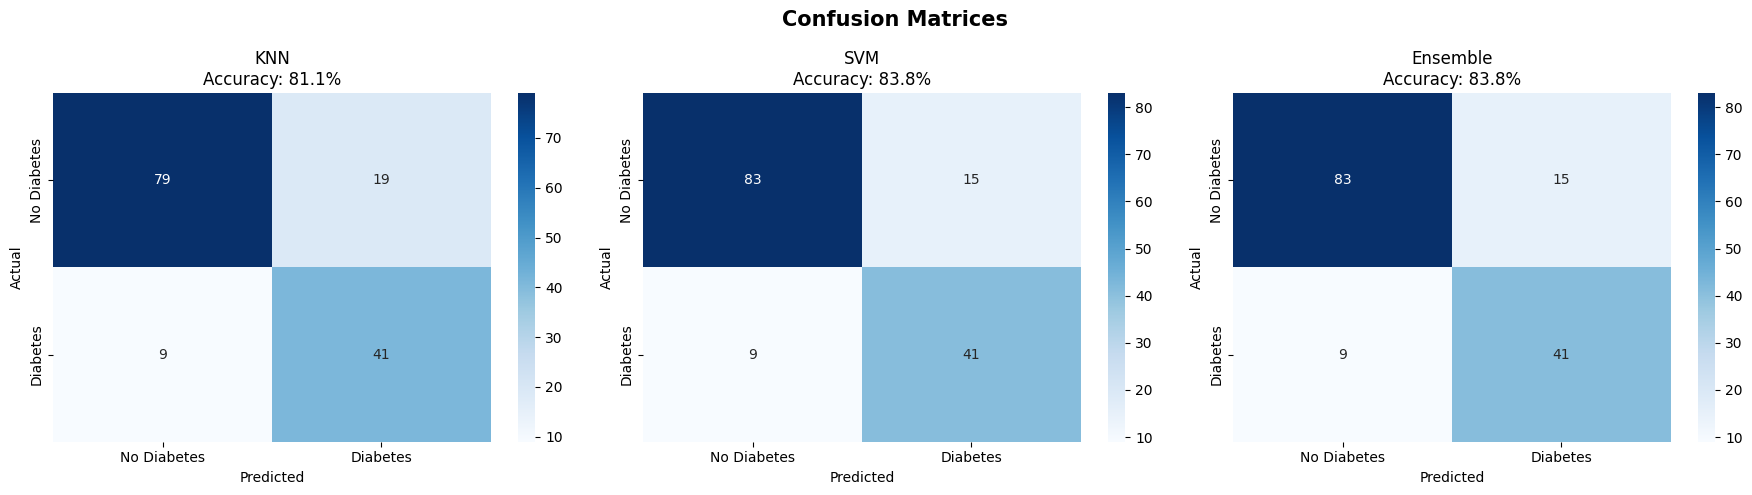

📊 Saved: confusion_matrices.png


In [50]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
 
for ax, name, preds in zip(axes,
                            ["KNN", "SVM", "Ensemble"],
                            [knn_preds, svm_preds, ensemble_preds]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, preds)*100:.1f}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
 
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()
print("📊 Saved: confusion_matrices.png")

In [51]:
# Saving Best Model

print("\n--- Model Comparison ---")
print(f"   KNN Accuracy      : {knn_acc * 100:.2f}%")
print(f"   SVM Accuracy      : {svm_acc * 100:.2f}%")
print(f"   Ensemble Accuracy : {ensemble_acc * 100:.2f}%")
 
# Pick the best among all three
all_models = {
    "KNN":      (best_knn,  knn_acc),
    "SVM":      (best_svm,  svm_acc),
    "Ensemble": (ensemble,  ensemble_acc),
}
 
best_model_name, (best_model, best_acc) = max(all_models.items(), key=lambda x: x[1][1])
 
print(f"\n   🏆 Best Model: {best_model_name} ({best_acc * 100:.2f}%)")
 
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler,     "scaler.pkl")
joblib.dump(selector,   "selector.pkl")
 
print(f"\n✅ Saved:")
print(f"   best_model.pkl  → {best_model_name}")
print(f"   scaler.pkl      → RobustScaler")
print(f"   selector.pkl    → SelectKBest (top {K})")


--- Model Comparison ---
   KNN Accuracy      : 81.08%
   SVM Accuracy      : 83.78%
   Ensemble Accuracy : 83.78%

   🏆 Best Model: SVM (83.78%)

✅ Saved:
   best_model.pkl  → SVM
   scaler.pkl      → RobustScaler
   selector.pkl    → SelectKBest (top 8)
